In [16]:
def parse_fleet(file):
    with open(file,"r") as f:
        lines = [line.strip() for line in f if line.strip()]
    i=0
    while i<len(lines):
        parts=lines[i].split()
        if "cvrp" in file:
            if len(parts)==1:
                vehcile_capacity=int(parts[0])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-2,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2])
                    })
                return {
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
        if "vrptw" in file:
          if len(parts)==2:
                number_of_vehicles=int(parts[0])
                vehcile_capacity=int(parts[1])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-2,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2]),
                        "time_window_opening":float(each_line[3]),
                        "time_window_closing":float(each_line[4]),
                        "service_time": float(each_line[5])
                    })
                return {
                    "number_of_vehicles": number_of_vehicles,
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
                
        i+=1
    return None

In [17]:
instance = parse_fleet("vrptw.txt")
instance

{'number_of_vehicles': 25,
 'vehicle_capacity': 200,
 'depot_coordinates': (35.0, 35.0),
 'customers': [{'id': 0,
   'x_coordinate': 41.0,
   'y_coordinate': 49.0,
   'demand': 10,
   'time_window_opening': 161.0,
   'time_window_closing': 171.0,
   'service_time': 10.0},
  {'id': 1,
   'x_coordinate': 35.0,
   'y_coordinate': 17.0,
   'demand': 7,
   'time_window_opening': 50.0,
   'time_window_closing': 60.0,
   'service_time': 10.0},
  {'id': 2,
   'x_coordinate': 55.0,
   'y_coordinate': 45.0,
   'demand': 13,
   'time_window_opening': 116.0,
   'time_window_closing': 126.0,
   'service_time': 10.0},
  {'id': 3,
   'x_coordinate': 55.0,
   'y_coordinate': 20.0,
   'demand': 19,
   'time_window_opening': 149.0,
   'time_window_closing': 159.0,
   'service_time': 10.0},
  {'id': 4,
   'x_coordinate': 15.0,
   'y_coordinate': 30.0,
   'demand': 26,
   'time_window_opening': 34.0,
   'time_window_closing': 44.0,
   'service_time': 10.0},
  {'id': 5,
   'x_coordinate': 25.0,
   'y_coord

In [18]:
class Customer:
    def __init__(self, id, x, y, demand, opening, closing, service_time) -> None:
        self.id = id
        self.x = x
        self.y = y
        self.demand = demand
        self.opening = opening
        self.closing = closing
        self.service_time = service_time

class VehicleStop:
    def __init__(self, customer_id, x, y, arrival_time, departure_time, remaining_capacity) -> None:
        self.customer_id = customer_id
        self.x = x
        self.y = y
        self.arrival_time = arrival_time
        self.departure_time = departure_time
        self.remaining_capacity = remaining_capacity

class VehicleSchedule:
    def __init__(self, vehicle_id, stops: list[VehicleStop]) -> None:
        self.vehicle_id = vehicle_id
        self.stops = stops

    def __repr__(self) -> str:
        return f"{self.vehicle_id}: {self.stops}"

class Solution:
    def __init__(self, schedules: list[VehicleSchedule]) -> None:
        self.schedules = schedules

    def __repr__(self) -> str:
        return f"{self.schedules}"

## GRASP baseline

In [19]:
import math
import random

def euclidian_distance(start_x, start_y, end_x, end_y):
    return math.sqrt((end_x - start_x) ** 2 + (end_y - start_y) ** 2) 

def construct(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha) -> Solution:
    not_visited_customers = customers.copy()
    schedules: list[VehicleSchedule] = []
    starting_point = VehicleStop(-1 , depot_coordinates[0], depot_coordinates[1], 0, 0, vehicle_capacity)

    # iterate over every vehicle and create a schedule for it
    for i in range(number_of_vehicles):
        stops: list[VehicleStop] = []
        current_capacity = vehicle_capacity
        # add stops to the schedule until we cannot guarantee time windows are met anymore
        feasible_customers = not_visited_customers
        while len(feasible_customers):
            last_stop = stops[-1] if len(stops) > 0 else starting_point
            # calculate cost for every customer and create RCL list
            cost_by_id = {
                c.id: euclidian_distance(last_stop.x, last_stop.y, c.x, c.y)
                for c in feasible_customers
            }

            min_cost = min(cost_by_id.values())
            max_cost = max(cost_by_id.values())
            threshold = min_cost + alpha * (max_cost - min_cost)

            rcl: list[Customer] = [c for c in feasible_customers if cost_by_id[c.id] <= threshold]
            chosen = random.choice(rcl)
            next_stop = VehicleStop(
                chosen.id, 
                chosen.x, 
                chosen.y, 
                max(chosen.opening, last_stop.departure_time), 
                max(chosen.opening, last_stop.departure_time) + chosen.service_time, 
                current_capacity - chosen.demand
            )
            
            stops.append(next_stop)
            not_visited_customers.remove(chosen)
            current_capacity = next_stop.remaining_capacity
            feasible_customers = [
                c for c in not_visited_customers
                if c.opening <= next_stop.departure_time <= c.closing
                and c.demand <= current_capacity
            ]
        
        vehicle_schedule = VehicleSchedule(i, stops)
        schedules.append(vehicle_schedule)
    
    return Solution(schedules)

def local_search():
    pass


def grasp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha: float, max_iterations: int) -> tuple[Solution, float]:
    best_solution: Solution = None
    best_cost = float("inf")

    for _ in range(max_iterations):
        print(customers)
        solution = construct(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha)
        best_solution = solution

    return best_solution, best_cost

In [20]:
number_of_vehicles = instance["number_of_vehicles"]
vehicle_capacity = instance["vehicle_capacity"]
depot_coordinates = instance["depot_coordinates"]
customer_dict = instance["customers"]

customers: list[Customer] = []
for c in customer_dict:
    customer = Customer(c["id"], c["x_coordinate"], c["y_coordinate"], c["demand"], c["time_window_opening"], c["time_window_closing"], c["service_time"])
    customers.append(customer)

RANDOMNESS = 0.3
MAX_ITERS = 25
solution, score = grasp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, RANDOMNESS, MAX_ITERS)

[<__main__.Customer object at 0x12a7cd7f0>, <__main__.Customer object at 0x104c7e710>, <__main__.Customer object at 0x12ab08f50>, <__main__.Customer object at 0x12a95c770>, <__main__.Customer object at 0x12a95c8a0>, <__main__.Customer object at 0x12a7aa9f0>, <__main__.Customer object at 0x12a7af130>, <__main__.Customer object at 0x12a7af240>, <__main__.Customer object at 0x12a8fb750>, <__main__.Customer object at 0x12a8fb950>, <__main__.Customer object at 0x12a9165d0>, <__main__.Customer object at 0x12a9164e0>, <__main__.Customer object at 0x104e21550>, <__main__.Customer object at 0x12a8b3690>, <__main__.Customer object at 0x12ab4bee0>, <__main__.Customer object at 0x104ea65d0>, <__main__.Customer object at 0x104ea6150>, <__main__.Customer object at 0x104e45a70>, <__main__.Customer object at 0x104e45e90>, <__main__.Customer object at 0x1047442d0>, <__main__.Customer object at 0x12a7eb750>, <__main__.Customer object at 0x12a8ce720>, <__main__.Customer object at 0x12a8eb750>, <__main__.

In [21]:
import matplotlib.pyplot as plt

def plot_solution(solution: Solution, customers: list[Customer], depot_coordinates: tuple[float, float], return_to_depot: bool = True):
    depot_x, depot_y = depot_coordinates

    # All customers (background)
    all_x = [c.x for c in customers]
    all_y = [c.y for c in customers]
    all_ids = [c.id for c in customers]

    plt.figure(figsize=(10, 8))
    plt.scatter(all_x, all_y, c="lightgray", s=50, label="Customers", zorder=1)

    # Optional customer id labels
    for cid, x, y in zip(all_ids, all_x, all_y):
        plt.text(x + 0.15, y + 0.15, str(cid), fontsize=8, color="gray")

    # Depot
    plt.scatter([depot_x], [depot_y], c="red", s=180, marker="*", label="Depot", zorder=5)

    cmap = plt.get_cmap("tab20")

    for schedule in solution.schedules:
        if not schedule.stops:
            continue

        color = cmap(schedule.vehicle_id % 20)

        # Route coordinates: depot -> stops -> depot (optional)
        route_x = [depot_x] + [s.x for s in schedule.stops]
        route_y = [depot_y] + [s.y for s in schedule.stops]
        if return_to_depot:
            route_x.append(depot_x)
            route_y.append(depot_y)

        plt.plot(
            route_x,
            route_y,
            color=color,
            linewidth=2,
            marker="o",
            markersize=4,
            label=f"Vehicle {schedule.vehicle_id}",
            zorder=3
        )

    plt.title("VRPTW Solution: Vehicle Routes")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(alpha=0.25)
    plt.legend(loc="best", fontsize=8)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

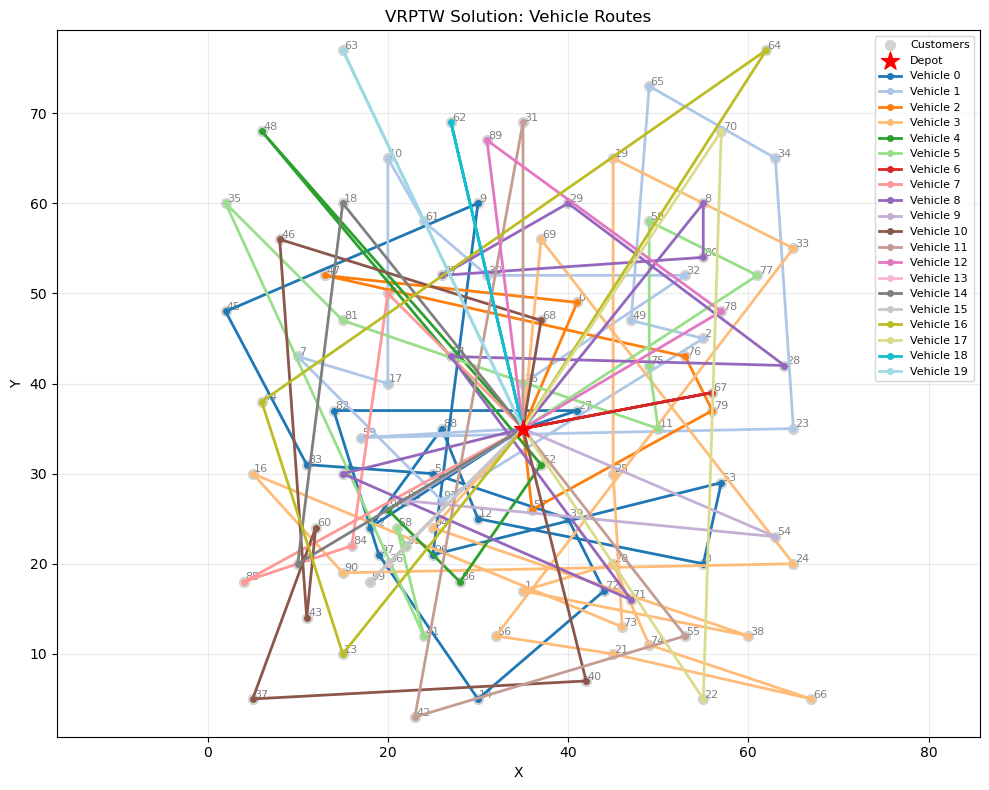

In [22]:
plot_solution(solution, customers, depot_coordinates)